# Downloading the Dataset

In [1]:
import os
import json
import urllib
import torch

In [2]:
def dowbload_and_load_file(file_path, url):
    if not os.path.exists(file_path):

        with urllib.request.urlopen(url) as response:
            text = response.read().decode("utf-8")
        
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text)
    
    else: # skip downloading
        with open(file_path, "r" , encoding="utf-8") as f:
            text_data = f.read()

    with open(file_path, "r") as file:
        data = json.load(file)

    return data



file_path = "instruction-data.json"

url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)


In [3]:
data = dowbload_and_load_file(file_path, url)

In [4]:
print(f"Number of data entires : {len(data)}")

Number of data entires : 1100


### Examples of the data

In [5]:
data[50]

{'instruction': 'Identify the correct spelling of the following word.',
 'input': 'Ocassion',
 'output': "The correct spelling is 'Occasion.'"}

In [6]:
data[999]

{'instruction': "What is an antonym of 'complicated'?",
 'input': '',
 'output': "An antonym of 'complicated' is 'simple'."}

**`As we saw, the Instruction Fine tuning Consists of 3 main componenets`**
1. `Instructions` : where it contains the instructions of the task
2. `Input` : input of the task 
3. `output` : the target we want to achieve

**`There is different techniques of transforming those fomrat to be passed to the llms`**


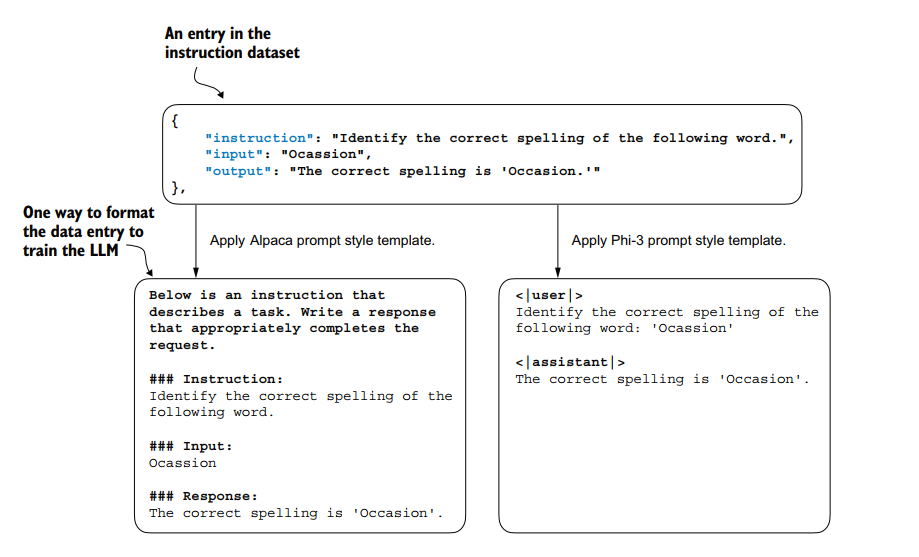

## Implementing the `Alpaca` Prompt Styling

In [7]:
data[1]["instruction"]

'Edit the following sentence for grammar.'

In [8]:
data[3]

{'instruction': "Rewrite this sentence to start with 'Although': Despite the rain, they went for a walk.",
 'input': '',
 'output': 'Although it was raining, they went for a walk.'}

**`This means if there is a record for this input : print that style "input: text`**

**`if the input is empty, dont print anything`**

In [9]:
input_text = (
    f"\n\n### Input: {data[3]["input"]}" if data[3]["input"] else ""
)
print(input_text)

In [10]:

def format_input(data):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{data["instruction"]}"
    )

    input_text = (
        f"\n\n### Input:\n{data["input"]}" if data["input"] else ""
    )

    return instruction_text + input_text





### Example 

In [11]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]["output"]}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


#### our function will skip the `input` if the input field is empty 

In [12]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]["output"]}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


# Partioning Dataset 

In [13]:
train_portion = int(0.85* len(data))
test_portion = int(0.1 * len(data))
val_portion = len(data) - test_portion - train_portion


In [14]:
train_data = data[:train_portion]
test_data = data[train_portion: train_portion +test_portion]
val_data = data[train_portion  : train_portion + val_portion ] 


print(f"Train data length : {len(train_data)}")
print(f"Val data length : {len(val_data)}")
print(f"Test data length : {len(test_data)}")

Train data length : 935
Val data length : 55
Test data length : 110


# Dataset Class

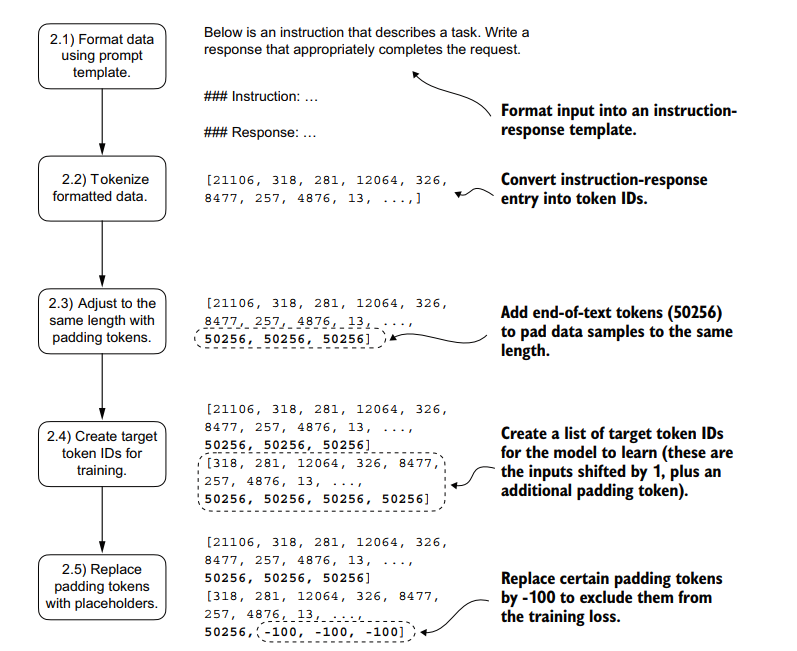

In [15]:
from torch.utils.data import Dataset

**`In the Dataset class, we will apply `Aplaca` template to each entry and encode the whole template`**

In [16]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):

        self.data = data
        self.encoded_texts = []
        
        # Encode each entry

        for entry in data:
            instruction_plus_input = format_input(entry)
            desired_response = f"\n\n### Response:\n{entry["output"]}"

            full_text = instruction_plus_input + desired_response

            self.encoded_texts.append(tokenizer.encode(full_text))

    
    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data)
    


In [17]:
import tiktoken

tokenizer= tiktoken.get_encoding("gpt2")
# lets see the token_id of <|endoftext|>

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))


[50256]


## Padding each sample in each batch
- To make sure all samples are equal in size and no error arrise during training

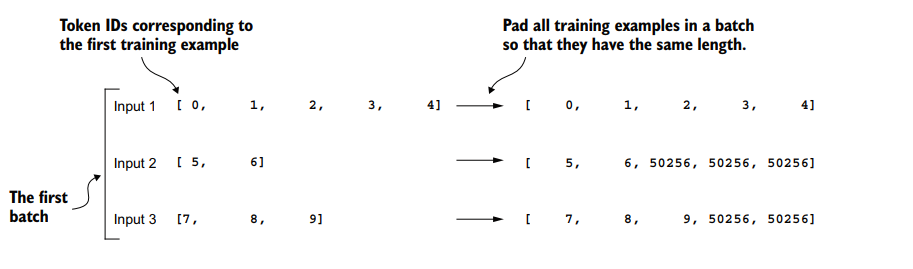

## Padding Function

In [18]:
def collate_draft_1(batch, pad_token=50256, device="cpu"):
    max_length_seq = max(len(item)+1 for item in batch)

    input_lst =[]

    for item in batch:
        new_item = item.copy()
        new_item +=[pad_token]

        padded = (new_item + [pad_token] * (max_length_seq - len(new_item)))

        # include all tokens except last one [newly added pad_tokens]
        input = torch.tensor(padded[:-1])
        input_lst.append(input)

    input_tensors = torch.stack(input_lst, dim=0)

    return input_tensors

In [19]:
in1 = [0,1,2,3,4]
in2 = [5,6]
in3 = [7,8,9]

batch =(in1, in2, in3)
print(collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


### We will create `input target` data to make model learn and update its weights

**`We need to add extra end token of <|endoftext|>`**


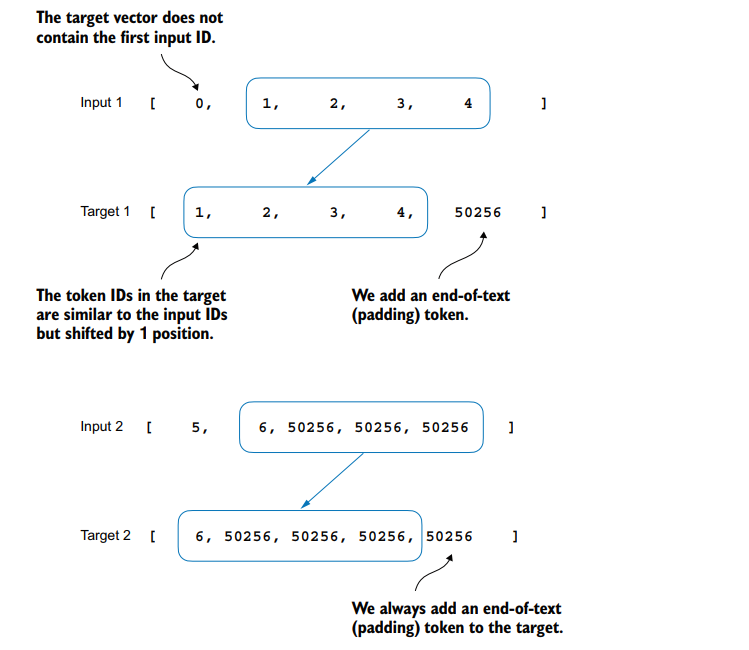

In [20]:
def collate_draft_2(batch, pad_token=50256, device="cpu"):

    max_length_seq = max(len(item)+1 for item in batch)

    inputs_lst=[]
    target_lst = []

    for item in batch:
        new_item =item.copy()
        new_item += [pad_token]

        padding = (new_item + [pad_token] *(max_length_seq - len(new_item)))

        input = torch.tensor(padding[:-1])

        # Shift +1 to the right for the targets
        targets = torch.tensor(padding[1:])

        inputs_lst.append(input)
        target_lst.append(targets)

    inpt_tensors = torch.stack(inputs_lst, dim=0).to(device)
    tgt_tensors = torch.stack(target_lst, dim=0).to(device)

    return inpt_tensors, tgt_tensors
    
        

In [21]:
input_tensors , target_tensors = collate_draft_2(batch)

print(f"Input tensors :\n{input_tensors}\n")
print(f"Target tensors :\n{target_tensors}")

Input tensors :
tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])

Target tensors :
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


## Replace the 50256 tokens with `-100` token 
- `we will do this for the interon tokens` 

- `But we will keep the last token as 50256 to make the model unerstands once it generated, it has to stop`

In [22]:
a = torch.tensor([2,3,4,5,6,123,31,23])
print(a)
b = torch.nonzero(a).squeeze()
print(b)
print(b.numel())

tensor([  2,   3,   4,   5,   6, 123,  31,  23])
tensor([0, 1, 2, 3, 4, 5, 6, 7])
8


**Important Note**
- mask = targets
    - now all values of targets are in mask
- mask = targets == pad_token
    - is a boolean comparison operator 
    - if mask value == pad_token, it returns true, otherwise false

In [23]:
targets   = torch.tensor([42, 99, 50256, 50256, 50256])
pad_token = 50256

mask = targets == pad_token
# mask = tensor([False, False, True, True, True])

indices= torch.nonzero(mask).squeeze()

print(f"mask : {mask}")
print(f"Print true indices: {indices}")
print(f"Count the number of indices found with true :{indices.numel()}")

mask : tensor([False, False,  True,  True,  True])
Print true indices: tensor([2, 3, 4])
Count the number of indices found with true :3


In [24]:
def custom_collate_fn(batch, pad_token = 50256, ingonre_index = -100 , allowed_max_length = None, device="cpu"):
    
    max_len_seq = max(len(item)+1 for item in batch)

    input_lst, target_lst = [], []

    for item in batch :
        new_item = item.copy()
        new_item += [pad_token]

        padding_garbage = new_item + [pad_token] * (max_len_seq - len(new_item))

        inputs = torch.tensor(padding_garbage[:-1])
        targets = torch.tensor(padding_garbage[1:])

        mask = targets == pad_token

        # non_zero, is index-like, starts from 0 to n 
        # squeeze, it converts the output of non-zero from column-wise into row-wise

        # indices : returns the true indices index
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() >1:
            targets[indices[1:]] = ingonre_index
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        
        input_lst.append(inputs)
        target_lst.append(targets)

    ipt_stack = torch.stack(input_lst, dim=0).to(device)
    tgt_stack = torch.stack(target_lst, dim=0).to(device)

    return ipt_stack, tgt_stack



In [25]:
inputs, targets = custom_collate_fn(batch)
print(inputs,"\n")
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]]) 

tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


## `Why we put [-100] instead of [<|endoftext|>] ?`

#### Lets see an example 

In [26]:
logits_1 = torch.tensor([[-1.0, 1],[-0.5,1.5]])
logits_1

tensor([[-1.0000,  1.0000],
        [-0.5000,  1.5000]])

In [27]:
# Lets say the true label as follow

target_1 = torch.tensor([0,1])
# for the 1st sample is 0 and for the 2nd sample is 1


## calc the loss using cross_entropy

loss_1 = torch.nn.functional.cross_entropy(logits_1,target_1)
print(f"Loss of the first loss : {loss_1}")

Loss of the first loss : 1.1269280910491943


In [28]:
## Lets add another example of 3 samples
logits_2 = torch.tensor([[-1.0, 1],[-0.5,1.5] , [-0.5, 1.5]])
target_2 = torch.tensor([0,1,1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, target_2)
print(f"Loss of the second loss : {loss_2}")

Loss of the second loss : 0.7935947775840759


In [29]:
## Another example, but lets make the last target with -100

target_3 = torch.tensor([0,1,-100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, target_3)
print(f"Loss of the second loss : {loss_3}")

Loss of the second loss : 1.1269280910491943


> **`What happens here, the cross entropy totally ignores the 3rd sample & target`**

- **And thats what we need, if the target, is -100, we dont need to calc its loss!**

but why -100 ? why not -49 or any number?
- Because cross_entropy(ignore_index = -100)


# DataLoaders

### we will re-create a new version of our `custom_collate_fn` with device to cuda and max_length to 1024 which is max length supported by `GPT-2`

In [30]:
from functools import partial

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
customized_collate_fn = partial(custom_collate_fn, device = device, allowed_max_length = 1024)


## DataLoader

In [31]:
train_data,test_data, val_data

([{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.',
   'input': 'freind --> friend',
   'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'},
  {'instruction': 'Edit the following sentence for grammar.',
   'input': 'He go to the park every day.',
   'output': 'He goes to the park every day.'},
  {'instruction': 'Convert 45 kilometers to meters.',
   'input': '',
   'output': '45 kilometers is 45000 meters.'},
  {'instruction': "Rewrite this sentence to start with 'Although': Despite the rain, they went for a walk.",
   'input': '',
   'output': 'Although it was raining, they went for a walk.'},
  {'instruction': 'What are the first 10 square numbers?',
   'input': '',
   'output': '1, 4, 9, 16, 25, 36, 49, 64, 81, 100.'},
  {'instruction': 'Suggest a more formal synonym for "happy."',
   'input': '',
   'output': 'A more formal synonym for "happy" is "content."'},
  {'instruction': 'Translate 

In [32]:
from torch.utils.data import DataLoader

num_workers = 0
num_batches = 8

torch.manual_seed(123)


# First we apply Aplaca Template to the train_dataset
train_dataset = InstructionDataset(train_data, tokenizer)

train_dataloader = DataLoader(train_dataset, batch_size=num_batches,collate_fn=customized_collate_fn , num_workers=num_workers, shuffle=True,drop_last=True)


## Apply the template to the val and test

val_dataset = InstructionDataset(val_data, tokenizer)
val_dataloader = DataLoader(val_dataset, batch_size=num_batches,collate_fn=customized_collate_fn ,num_workers=num_workers,shuffle=False, drop_last=False)

#test_dataset = InstructionDataset(test_data, tokenizer)
#test_dataloader = DataLoader(test_dataset, batch_size=num_batches, num_workers=num_workers, collate_fn=customized_collate_fn, shuffle=False, drop_last=False)



In [33]:
print("Train Loader")
for inputs, targets in train_dataloader:
    print(inputs.shape, targets.shape)

Train Loader
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.S

# Loading Pre-Trained Model `gpt-2`

In [34]:
from gpt import GPTModel

BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
INPUT_PROMPT = "Every Efforts moves you"

In [35]:
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load("gpt2-small-124M.pth"))

<All keys matched successfully>

## Lets see an example of our model 

- How it answer one of val_data example

In [36]:
def generate(model, idx, max_new_tokens, context_size, temp =0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]

            logits = torch.where(condition=logits < min_val,
                                 input = torch.tensor(float("-inf")).to(logits.device),
                                 other = logits)

        if temp > 0.0:
            logits = logits / temp
            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probas = torch.softmax(logits, dim=-1)
            next_token_id = torch.multinomial(probas, num_samples=1)

        else:
            #probas = torch.softmax(logits, dim=0)
            next_token_id = torch.argmax(logits,dim =-1 , keepdim=True)
        if next_token_id == eos_id:
            break
        idx = torch.cat((idx, next_token_id),dim = 1)
    return idx 

In [37]:
from gpt_training import generate_text_sample, token_ids_to_text, text_to_token
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.


In [38]:
token_ids = generate(model, text_to_token(tokenizer, input_text), max_new_tokens=35, context_size=BASE_CONFIG["context_length"],eos_id=50256)
generated_text = token_ids_to_text(tokenizer, token_ids)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

### Output:

The car is very fast.

### Error:

The car is very fast.

### Error:

The car


In [39]:
# get only the generated text

stripped_text = generated_text[len(input_text):].strip()
print(stripped_text)

### Output:

The car is very fast.

### Error:

The car is very fast.

### Error:

The car


**`> Bad Generation : the output shows that the model are not capable of following instructions`**

### Calc the `inital total loss` before training

In [40]:
from gpt_training import train_model_simple, calc_loss_loader

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_dataloader, model, device)
    val_loss = calc_loss_loader(val_dataloader, model, device)

print(f"Training Loss : {train_loss}")
print(f"Validation Loss : {val_loss}")


Training Loss : 4.087730019256987
Validation Loss : 4.217037882123675


# Training 

In [41]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(),lr=0.00005 , weight_decay=0.1)
num_epochs = 5


train_losses, val_losses, tokens_seen = train_model_simple(train_dataloader,
                                                           val_dataloader,
                                                           optimizer,
                                                           model,
                                                           device,
                                                           num_epochs,
                                                           eval_freq=5,
                                                           eval_iter=5,
                                                           start_context=format_input(val_data[0]),
                                                           tokenizer=tokenizer)


end_time = time.time()

exec_time_in_minutes = (end_time - start_time) / 60

print(f"Training Completed in {exec_time_in_minutes:.2f} minutes.")


Ep 1 (step 000000)  Train Loss : 3.119 Validation Loss :3.128
Ep 1 (step 000005)  Train Loss : 1.697 Validation Loss :1.546
Ep 1 (step 000010)  Train Loss : 1.095 Validation Loss :1.129
Ep 1 (step 000015)  Train Loss : 1.053 Validation Loss :1.036
Ep 1 (step 000020)  Train Loss : 0.970 Validation Loss :0.980
Ep 1 (step 000025)  Train Loss : 0.920 Validation Loss :0.946
Ep 1 (step 000030)  Train Loss : 0.960 Validation Loss :0.924
Ep 1 (step 000035)  Train Loss : 0.878 Validation Loss :0.912
Ep 1 (step 000040)  Train Loss : 0.846 Validation Loss :0.903
Ep 1 (step 000045)  Train Loss : 0.777 Validation Loss :0.888
Ep 1 (step 000050)  Train Loss : 0.869 Validation Loss :0.876
Ep 1 (step 000055)  Train Loss : 0.924 Validation Loss :0.851
Ep 1 (step 000060)  Train Loss : 0.873 Validation Loss :0.837
Ep 1 (step 000065)  Train Loss : 0.800 Validation Loss :0.833
Ep 1 (step 000070)  Train Loss : 0.694 Validation Loss :0.832
Ep 1 (step 000075)  Train Loss : 0.707 Validation Loss :0.827
Ep 1 (st

In [45]:
val_data

[{'instruction': 'Rewrite the sentence using a simile.',
  'input': 'The car is very fast.',
  'output': 'The car is as fast as lightning.'},
 {'instruction': 'What type of cloud is typically associated with thunderstorms?',
  'input': '',
  'output': 'The type of cloud typically associated with thunderstorms is cumulonimbus.'},
 {'instruction': "Name the author of 'Pride and Prejudice'.",
  'input': '',
  'output': 'Jane Austen.'},
 {'instruction': 'What is the periodic symbol for chlorine?',
  'input': '',
  'output': 'The periodic symbol for chlorine is Cl.'},
 {'instruction': 'Correct the punctuation in the sentence.',
  'input': 'Its time to go home.',
  'output': "The corrected sentence should be: 'It's time to go home.'"},
 {'instruction': 'Rewrite the sentence.',
  'input': 'The lecture was delivered in a clear manner.',
  'output': 'The lecture was delivered clearly.'},
 {'instruction': 'Generate a humorous anecdote.',
  'input': '',
  'output': 'Why was the math book sad? Bec

# Plotting Losses

In [42]:
import matplotlib.pyplot as plt

def plot_losses(train_loss, val_loss, epochs_seen, tokens_seen):
    fig , ax_1 = plt.subplots(figsize=(10,5))
    ax_1.plot(epochs_seen , train_loss , label="Training Loss")
    ax_1.plot(epochs_seen, val_loss, label="Validation Loss" , linestyle="-.")
    ax_1.set_xlabel("Epochs")
    ax_1.set_ylabel("Loss")
    ax_1.legend(loc = "upper right")
    fig.tight_layout()
    plt.show()




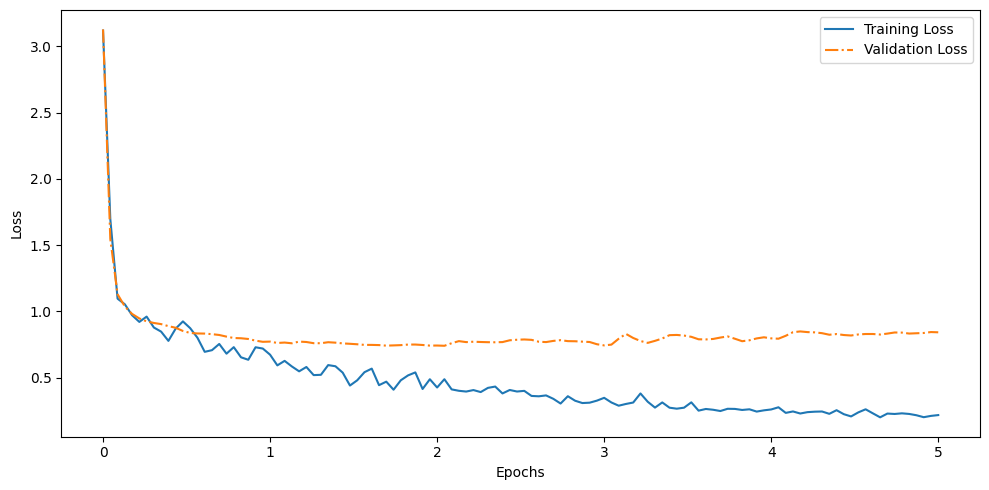

In [43]:
epochs_tensors = torch.linspace(0,num_epochs, len(train_losses))

plot_losses(train_losses, val_losses, epochs_tensors,tokens_seen)

# Test the model after Fine-Tuning

In [44]:
torch.manual_seed(123)

for entry in val_data[:3]:
    input_text = format_input(entry)
    token_ids= generate(model, idx=text_to_token(tokenizer, input_text).to(device), max_new_tokens=256, context_size=BASE_CONFIG["context_length"],eos_id=50256)


    generated_text = token_ids_to_text(tokenizer, token_ids)

    response_text = (
        generated_text[len(input_text) :]
        .replace("### Response:","")
        .strip()

        )
    
    print(input_text)

    print(f"\nCorrect response:\n>> {entry["output"]}")
    print(f"\nModel response:\n>> {response_text.strip()}")

    print("----------------------------------------")
    

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
----------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud typically associated with thunderstorms is a cumulus clouds type.
----------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The au

## Test all test_dataloader

In [47]:
from tqdm import tqdm

for i , entry in tqdm(enumerate(test_data), total = len(test_data)):
    input_text = format_input(entry)
    token_ids= generate(model, idx=text_to_token(tokenizer, input_text).to(device), max_new_tokens=256, context_size=BASE_CONFIG["context_length"],eos_id=50256)


    generated_text = token_ids_to_text(tokenizer, token_ids)

    response_text = (
        generated_text[len(input_text) :]
        .replace("### Response:","")
        .strip()

        )
    
    test_data[i]["model_response"] = response_text



with open("instruction-data-with-response.json" ,"w") as file:
    json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [00:55<00:00,  1.97it/s]


In [49]:
test_data[1]

{'instruction': 'What type of cloud is typically associated with thunderstorms?',
 'input': '',
 'output': 'The type of cloud typically associated with thunderstorms is cumulonimbus.',
 'model_response': 'The type of cloud typically associated with thunderstorms is a cumulus clouds type.'}

## Saving Model 

In [50]:
torch.save(model.state_dict() , "gpt2-instruct.pth")